## Bibliotecas usadas em todos exercícios

In [32]:
%pip install networkx
%pip install matplotlib

import networkx as nx
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\paulo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\paulo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Exercício 1 — Rede de amizades

Crie um grafo não direcionado representando a seguinte rede de amizades.

| Pessoa | Amigos |
|---------|---------|
| Ana | Bruno, Carla |
| Bruno | Ana, Daniel, Eduardo |
| Carla | Ana, Daniel |
| Daniel | Bruno, Carla, Eduardo |
| Eduardo | Bruno, Daniel |

1. Construa o grafo utilizando o **NetworkX**.
2. Desenhe o grafo com os nomes dos vértices.
3. Imprima:
   - número de vértices;
   - número de arestas;
   - lista de vértices;
   - lista de arestas.
4. Remova a amizade entre **Bruno** e **Eduardo** e desenhe novamente o grafo.


In [33]:
G1 = nx.Graph()

Adicionando nós e conexões

In [34]:
G1.add_node('Ana')
G1.add_node('Bruno')
G1.add_node('Carla')
G1.add_node('Daniel')
G1.add_node('Eduardo')

G1.add_edge('Ana','Bruno')
G1.add_edge('Ana','Carla')
G1.add_edge('Bruno','Ana')
G1.add_edge('Bruno','Daniel')
G1.add_edge('Bruno','Eduardo')
G1.add_edge('Carla','Ana')
G1.add_edge('Carla','Daniel')
G1.add_edge('Daniel','Bruno')
G1.add_edge('Daniel','Carla')
G1.add_edge('Daniel','Eduardo')
G1.add_edge('Eduardo','Bruno')
G1.add_edge('Eduardo','Daniel')

Visualizando grafo

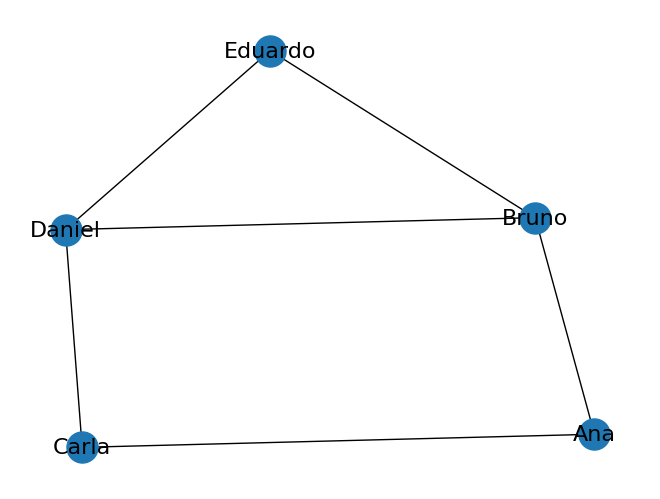

In [35]:
pos1 = nx.spring_layout(G1)
nx.draw(G1, with_labels=True, node_size=500, font_size=16, pos=pos1)
plt.show()

Imprimindo dados

In [36]:
print(f'O número de vertices é {len(G1.nodes())}')

print(f'O número de arestas é {len(G1.edges())}')

print(f'Os vertices são: {list(G1.nodes)}')

print(f'As arestas são: {list(G1.edges)}')

O número de vertices é 5
O número de arestas é 6
Os vertices são: ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eduardo']
As arestas são: [('Ana', 'Bruno'), ('Ana', 'Carla'), ('Bruno', 'Daniel'), ('Bruno', 'Eduardo'), ('Carla', 'Daniel'), ('Daniel', 'Eduardo')]


Removendo amizade entre Bruno e Eduardo e visualizando o grafo novamente

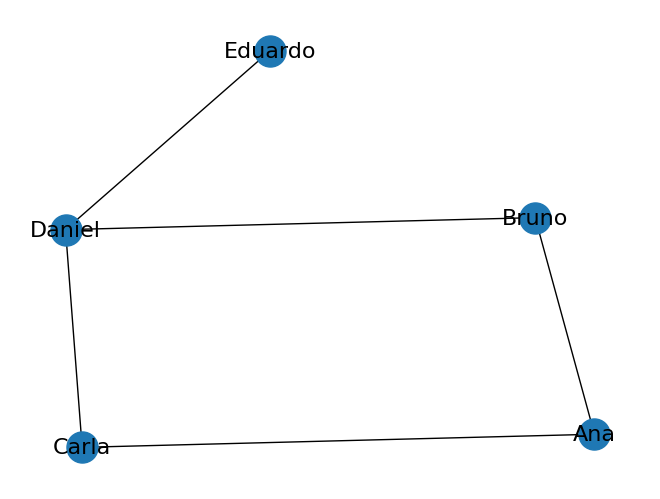

In [37]:
G1.remove_edge('Bruno','Eduardo')

nx.draw(G1, with_labels=True, node_size=500, font_size=16, pos=pos1)
plt.show()

## Exercício 2 — Mapa simplificado do metrô

Considere o seguinte mapa simplificado de estações:

```text
A ----- B ----- C
|       |
|       |
D ----- E ----- F
```

Cada ligação possui o seguinte tempo (em minutos):

| Ligação | Tempo |
|----------|------:|
| A–B | 3 |
| B–C | 2 |
| A–D | 5 |
| D–E | 4 |
| B–E | 6 |
| E–F | 3 |

1. Construa um **grafo ponderado** utilizando o NetworkX.
2. Desenhe o grafo exibindo os pesos das arestas.
3. Imprima o peso da ligação entre **D** e **E**.
4. Adicione uma nova ligação entre **C** e **F** com peso igual a 4.
5. Exiba novamente o grafo.


In [38]:
G2 = nx.Graph()

In [39]:
G2.add_node('A')
G2.add_node('B')
G2.add_node('C')
G2.add_node('D')
G2.add_node('E')
G2.add_node('F')

G2.add_edge('A','B',time=3)
G2.add_edge('B','C',time=2)
G2.add_edge('A','D',time=5)
G2.add_edge('D','E',time=4)
G2.add_edge('B','E',time=6)
G2.add_edge('E','F',time=3)

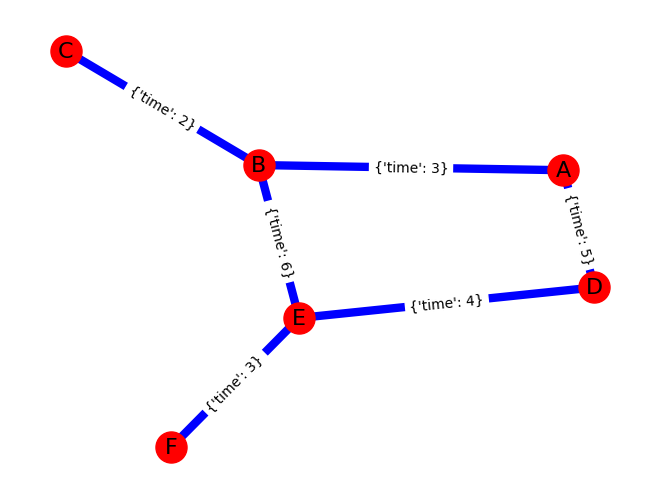

In [40]:
pos2 = nx.spring_layout(G2)
nx.draw(G2, with_labels=True, node_color='r', edge_color='b',
        node_size=500, font_size=16, pos=pos2, width=6)
nx.draw_networkx_edge_labels(G2, pos2)
plt.show()

In [41]:
print(G2.edges['D','E'])

{'time': 4}


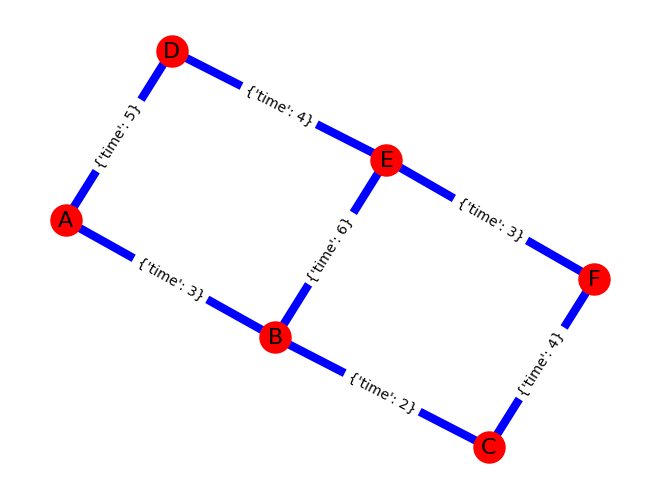

In [42]:
G2.add_edge('C','F',time=4)

pos2 = nx.spring_layout(G2)
nx.draw(G2, with_labels=True, node_color='r', edge_color='b',
        node_size=500, font_size=16, pos=pos2, width=6)
nx.draw_networkx_edge_labels(G2, pos2)
plt.show()

## Exercício 3 — Grafo a partir de uma matriz de adjacência

Considere a seguinte matriz de adjacência:

```python
A = np.array([
    [0,1,1,0,0,0],
    [1,0,1,1,0,0],
    [1,1,0,0,1,0],
    [0,1,0,0,1,1],
    [0,0,1,1,0,1],
    [0,0,0,1,1,0]
])
```

1. Construa o grafo correspondente.
2. Desenhe o grafo.
3. Imprima todos os vizinhos do vértice `2`.
4. Verifique se existe uma aresta entre os vértices `0` e `5`.
5. Calcule o grau de cada vértice.


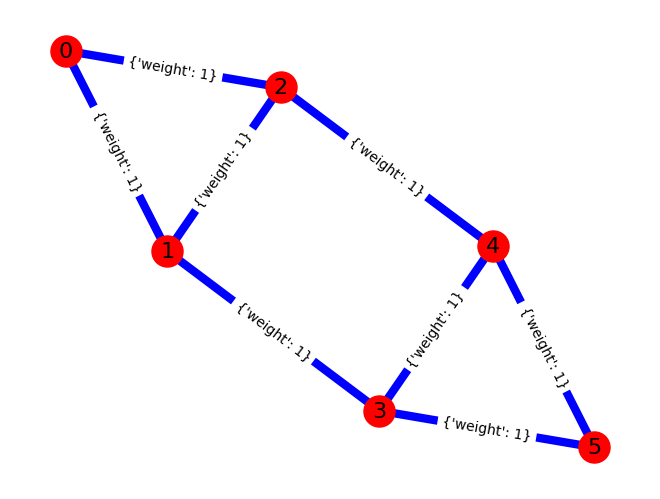

In [43]:
import numpy as np

A = np.array([
    [0,1,1,0,0,0],
    [1,0,1,1,0,0],
    [1,1,0,0,1,0],
    [0,1,0,0,1,1],
    [0,0,1,1,0,1],
    [0,0,0,1,1,0]
])

# nx.from_numpy_array converte uma matriz de adjacências (array do NumPy) em um objeto Graph do NetworkX
# (em versões antigas do NetworkX, essa função se chamava from_numpy_matrix -- hoje descontinuada)
G3 = nx.from_numpy_array(A)

pos3 = nx.spring_layout(G3)
nx.draw(G3, with_labels=True, node_color='r', edge_color='b',
        node_size=500, font_size=16, pos=pos3, width=6)
nx.draw_networkx_edge_labels(G3, pos3)
plt.show()

Vizinho do vértice `2`

In [44]:
print(f'Os vizinhos do nó 2 são {list(G3.neighbors(2))}')

Os vizinhos do nó 2 são [0, 1, 4]


In [45]:
for no in G3.nodes():
    print(f'O grau do vértice {no} é: {len(list(G3.neighbors(no)))}')

O grau do vértice 0 é: 2
O grau do vértice 1 é: 3
O grau do vértice 2 é: 3
O grau do vértice 3 é: 3
O grau do vértice 4 é: 3
O grau do vértice 5 é: 2


## Exercício 4 — Rede de voos (grafo direcionado)

Considere as seguintes rotas aéreas:

| Origem | Destino |
|---------|----------|
| São Paulo | Rio de Janeiro |
| Rio de Janeiro | Brasília |
| Brasília | Salvador |
| Salvador | Recife |
| Recife | São Paulo |
| São Paulo | Brasília |

1. Construa um **grafo direcionado** (`DiGraph`).
2. Desenhe o grafo utilizando setas.
3. Imprima:
   - todos os vértices;
   - todas as arestas.
4. Adicione uma nova rota entre **Brasília** e **São Paulo**.
5. Imprima o número de ligações de entrada (*in-degree*) e de saída (*out-degree*) de cada cidade.


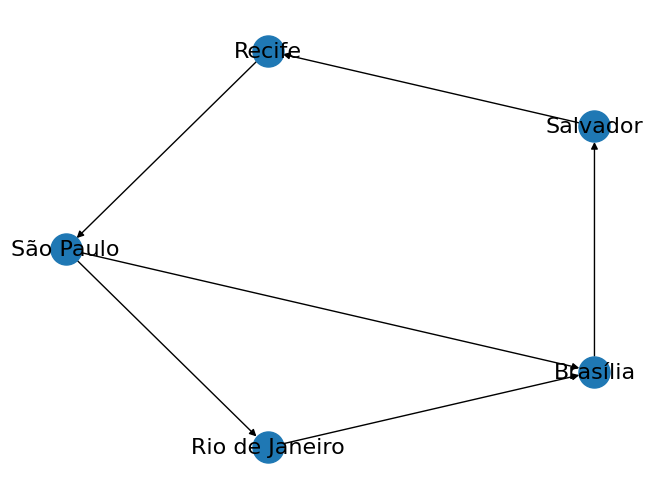

In [46]:
edgelist = [('São Paulo', 'Rio de Janeiro'), ('Rio de Janeiro', 'Brasília'), ('Brasília', 'Salvador'), ('Salvador', 'Recife'), ('Recife', 'São Paulo'), ('São Paulo', 'Brasília')]
G4 = nx.DiGraph(edgelist)

pos4 = nx.shell_layout(G4)
nx.draw(G4, with_labels=True, node_size=500, font_size=16, pos=pos4)
plt.show()

In [47]:
print(f'Os nós (locais) disponíveis no grafo são: {list(G4.nodes)}')
print(f'As arestas (rotas) disponíveis no grafo são: {list(G4.edges)}')

Os nós (locais) disponíveis no grafo são: ['São Paulo', 'Rio de Janeiro', 'Brasília', 'Salvador', 'Recife']
As arestas (rotas) disponíveis no grafo são: [('São Paulo', 'Rio de Janeiro'), ('São Paulo', 'Brasília'), ('Rio de Janeiro', 'Brasília'), ('Brasília', 'Salvador'), ('Salvador', 'Recife'), ('Recife', 'São Paulo')]


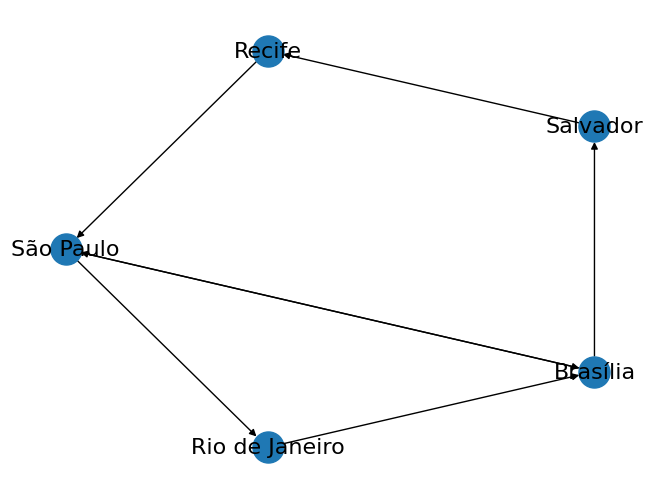

In [48]:
G4.add_edge('Brasília', 'São Paulo')

pos4 = nx.shell_layout(G4)
nx.draw(G4, with_labels=True, node_size=500, font_size=16, pos=pos4)
plt.show()

In [49]:
for no in G4.nodes():
    print(f"Nó: {no}")
    print(f"  In-degree : {G4.in_degree(no)}")
    print(f"  Out-degree: {G4.out_degree(no)}")

Nó: São Paulo
  In-degree : 2
  Out-degree: 2
Nó: Rio de Janeiro
  In-degree : 1
  Out-degree: 1
Nó: Brasília
  In-degree : 2
  Out-degree: 2
Nó: Salvador
  In-degree : 1
  Out-degree: 1
Nó: Recife
  In-degree : 1
  Out-degree: 1


## Exercício 5 — Rede de páginas da Wikipédia

Considere as seguintes páginas da Wikipédia:

- Python
- NumPy
- Pandas
- Matplotlib
- NetworkX
- Ciência de Dados

Uma página possui um link para outra quando indicado abaixo:

```python
[
    ("Python", "NumPy"),
    ("Python", "Pandas"),
    ("Python", "Matplotlib"),
    ("Python", "NetworkX"),
    ("NumPy", "Pandas"),
    ("Pandas", "Matplotlib"),
    ("Pandas", "Ciência de Dados"),
    ("NetworkX", "Ciência de Dados"),
    ("Matplotlib", "Ciência de Dados")
]
```

1. Construa um **grafo direcionado** utilizando essa lista de arestas.
2. Desenhe o grafo.
3. Para cada página, imprima:
   - número de links de saída;
   - número de links de entrada.
4. Adicione uma ligação entre **NetworkX** e **Matplotlib**.
5. Renomeie todos os vértices para números inteiros utilizando `convert_node_labels_to_integers()`.
6. Qual página possui o maior número de links de entrada? E o maior número de links de saída?

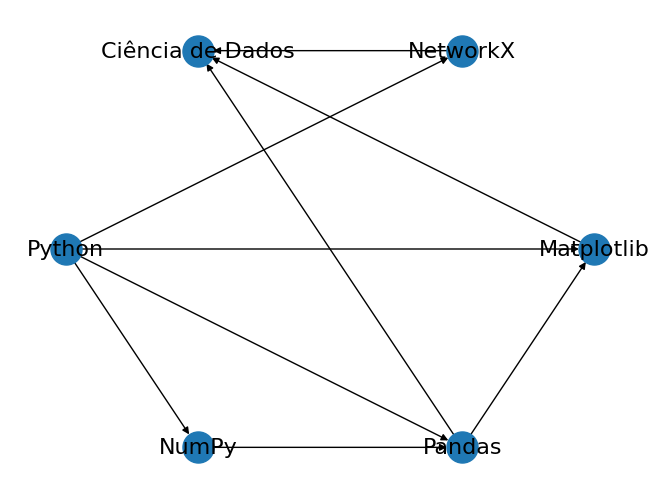

In [50]:
edgelist = [
    ("Python", "NumPy"),
    ("Python", "Pandas"),
    ("Python", "Matplotlib"),
    ("Python", "NetworkX"),
    ("NumPy", "Pandas"),
    ("Pandas", "Matplotlib"),
    ("Pandas", "Ciência de Dados"),
    ("NetworkX", "Ciência de Dados"),
    ("Matplotlib", "Ciência de Dados")
]
G5 = nx.DiGraph(edgelist)

pos5 = nx.shell_layout(G5)
nx.draw(G5, with_labels=True, node_size=500, font_size=16, pos=pos5)
plt.show()

In [51]:
for no in G5.nodes():
    print(f"Nó: {no}")
    print(f"  In-degree : {G5.in_degree(no)}")
    print(f"  Out-degree: {G5.out_degree(no)}")

Nó: Python
  In-degree : 0
  Out-degree: 4
Nó: NumPy
  In-degree : 1
  Out-degree: 1
Nó: Pandas
  In-degree : 2
  Out-degree: 2
Nó: Matplotlib
  In-degree : 2
  Out-degree: 1
Nó: NetworkX
  In-degree : 1
  Out-degree: 1
Nó: Ciência de Dados
  In-degree : 3
  Out-degree: 0


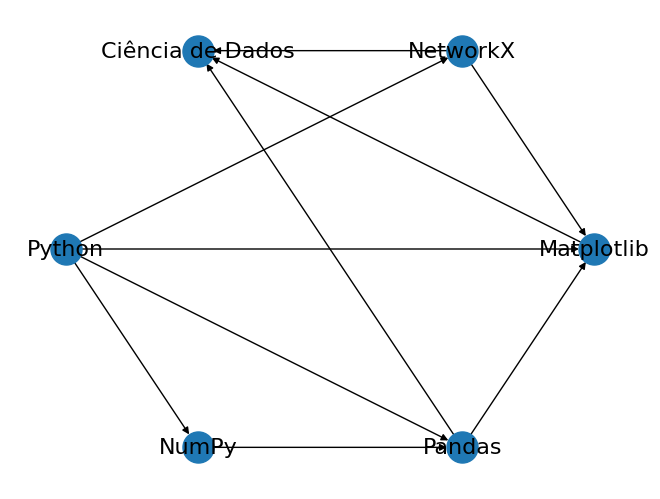

In [52]:
G5.add_edge('NetworkX','Matplotlib')

pos5 = nx.shell_layout(G5)
nx.draw(G5, with_labels=True, node_size=500, font_size=16, pos=pos5)
plt.show()

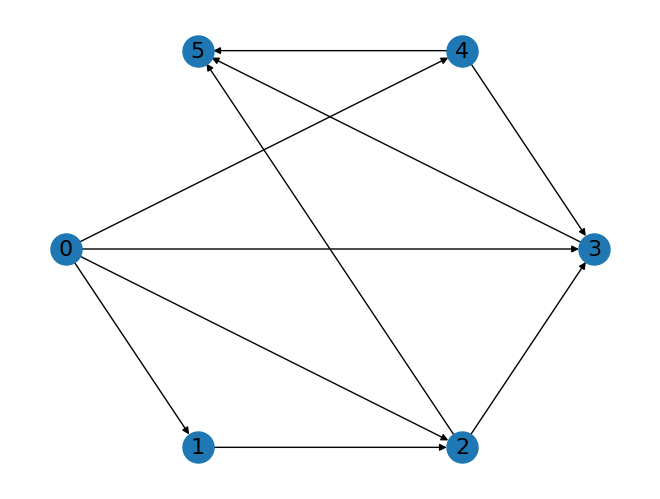

In [53]:
G6 = nx.convert_node_labels_to_integers(G5, first_label=0, ordering="default", label_attribute="nome_site")

pos5 = nx.shell_layout(G6)
nx.draw(G6, with_labels=True, node_size=500, font_size=16, pos=pos5)
plt.show()

In [54]:
# Grau de entrada e saída de cada nó
in_degrees = dict(G5.in_degree())
out_degrees = dict(G5.out_degree())

no_max_entrada = max(in_degrees, key=in_degrees.get)
print(f"Página com mais links de entrada: nó {no_max_entrada} (in-degree = {in_degrees[no_max_entrada]})")

no_max_saida = max(out_degrees, key=out_degrees.get)
print(f"Página com mais links de saída: nó {no_max_saida} (out-degree = {out_degrees[no_max_saida]})")

Página com mais links de entrada: nó Matplotlib (in-degree = 3)
Página com mais links de saída: nó Python (out-degree = 4)
